# Homework 3

Some admin stuff:

- From a code perspective, we prefer modular development, so we had files for each part
of the process. All code is pasted at the bottom in the Appendix. 
- Runnable on a colab GPU. Just adjust 
`COLAB_DIR = Path("/content/drive/MyDrive/path/to/root/folder")` in `config.py` as per
your requirements

In [1]:
import re
import json
from dataclasses import asdict
from IPython.display import Image

import pandas as pd
import torch

from config import (
    DataConfig,
    GlobalTrainingConfig,
    RunConfig,
    TokenConfig,
    TokenizationConfig,
    ModelConfig,
)
from models import TokenChunkDataset, load_model
from tokenizer import (
    build_token_memmap,
    build_tokenizer,
    iter_stories,
    count_tokens,
    get_token_vector,
    find_closest_tokens,
)
from results import load_training_result, load_generations, generations_to_dataframe
from training import train_model
from utils import save_json
from plot import plot_training_curves, plot_validation_curves

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)  # optional
pd.set_option("display.max_columns", None)  # optional
pd.set_option("display.width", None)  # optional
pd.options.display.float_format = "{:,.2f}".format

The ultimate torch device variable

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


cpu


The config objects make our life a lot easier – one central place to manage all the 
different configuration values

In [4]:
token_config = TokenConfig()
data_config = DataConfig()
global_training_config = GlobalTrainingConfig()
tokenization_config = TokenizationConfig()
run_config = RunConfig("hw3-submission")

# load all the results and the most recent model
results = {
    name: load_training_result(run_config.metrics / f"{name}.json")
    for name in [
        "1_base_steps=1k_vocab=3k",
        "2_base_steps=100k",
        "3_large-plus",
        "4_large-plus_vocab=5k",
        "5_xlarge-plus",
        "6_xlarge-plus_context=512",
    ]
}
print("Loaded results")

model = load_model(run_config.models / "5_xlarge-plus.pt", device)
print("Loaded model")

Directory already exists: /Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/runs/hw3-submission
Loaded results
Loaded model


## (a) Tokenizer

We trained a BPE tokenizer with vocabulary size 3,000 on the first 1,000,000 training 
stories. BPE starts from a small inventory of characters or character-like pieces and 
repeatedly merges frequent adjacent pairs, so common fragments become single tokens 
while rare words still fall back to smaller subwords. This is preferable to pure 
character tokenization because the sequence length becomes much shorter, and it is 
preferable to full word tokenization because rare words and misspellings can still be 
represented without an exploding vocabulary.

For this notebook we used a metaspace BPE setup so spaces are preserved on decode, and 
we reserved the special tokens `<pad>`, `<bos>`, `<eos>`, and `<unk>`.

We also printed out 5 sentences from the first story, looked at the word count vs. token 
count, to see what tokens the tokenizer was picking up. The outputs are below

In [5]:
# build_tokenizer will load the tokenizer if we already trained it
tokenizer = build_tokenizer(
    tokenization_config, token_config, data_config.training_file_local
)

for item in iter_stories(tokenization_config, data_config.training_file_local):
    sentences = re.split(r"[.\n!?]+", item)
    for sentence in sentences[:2]:
        word_count = len(sentence.split(" "))
        encodings = tokenizer.encode(sentence)
        print(f"{sentence} has {word_count} words and {len(encodings)} tokens:")
        print(f"  {tuple(zip(encodings.tokens[:3], encodings.ids[:3]))}")
    break

Found it in /Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/shared/tokenizers/tinystories_bpe_metaspace_5000_1000000.json, loading from there
Once upon a time there was a little boy named Ben has 11 words and 11 tokens:
  (('▁Once', 363), ('▁upon', 372), ('▁a', 191))
 Ben loved to explore the world around him has 9 words and 8 tokens:
  (('▁Ben', 480), ('▁loved', 442), ('▁to', 198))


The above print / display statements illustrate the tokenization process on the first 3 
sentences of the first story

## (b) Create the dataset

We concatenated tokenized stories into one long stream, appending <eos> after every story, and then chunked that stream into non-overlapping windows of length 128. For each chunk, the input is tokens t_0, ..., t_{L-1} and the target is the same chunk shifted by one position, which implements standard next token prediction.

The results were:
- **Train:** Train has 37,781,992 tokens and 295,171 samples
- **Validation:** Train has 5,184,076 tokens and 40,500 samples

In [6]:
train_token_count = count_tokens(
    tokenization_config, tokenizer, data_config.training_file_local
)
valid_token_count = count_tokens(
    tokenization_config, tokenizer, data_config.validation_file_local
)

train_token_memmap_path = build_token_memmap(
    tokenization_config,
    token_config,
    tokenizer,
    data_config.training_file_local,
    train_token_count,
)
valid_token_memmap_path = build_token_memmap(
    tokenization_config,
    token_config,
    tokenizer,
    data_config.validation_file_local,
    valid_token_count,
)

training_samples = int(train_token_count / global_training_config.context_length)
display(f"Train has {train_token_count} tokens and {training_samples} samples")

validation_samples = int(valid_token_count / global_training_config.context_length)
display(f"Validation has {valid_token_count} tokens and {validation_samples} samples")

train_dataset = TokenChunkDataset(
    train_token_memmap_path, train_token_count, global_training_config.context_length
)
valid_dataset = TokenChunkDataset(
    valid_token_memmap_path, valid_token_count, global_training_config.context_length
)

'Train has 176680096 tokens and 345078 samples'

'Validation has 4850935 tokens and 9474 samples'

## (c) Model

We used a pre norm decoder only transformer with sinusoidal positional encoding and tied
input/output embeddings. The data flow is:

Input token IDs
→ Token embedding
→ + Sinusoidal position encoding
→ Transformer blocks (causal self-attention + feed-forward)
→ Final layer norm
→ Tied output projection
→ Next token logits

Each transformer block uses multi-head causal self attention with 
`scaled_dot_product_attention(..., is_causal=True)`, followed by a GELU feed forward 
network, residual connections, and layer normalization. Weight tying means the output 
projection reuses the token embedding matrix, which is standard in language models and 
keeps the parameter count lower.

We trained a total of 17 different models. The final model's parameter count was 
**46,368,768**. All the model architectural details are summarized in the table below. 
and the 46M model whose results we will be discussing is called xlarge-plus

In [8]:
all_trained_models = pd.DataFrame(
    {
        **dict(results[k].config),
        "parameter_count": results[k].parameter_count,
        "final_training_loss": results[k].training_losses[-1],
        "final_validation_loss": results[k].validation_losses[-1],
        "real_name": k,
    }
    for k in results.keys()
)
display(
    all_trained_models[
        [
            "real_name",
            "parameter_count",
            "final_training_loss",
            "final_validation_loss",
            "max_steps",
            "warmup_steps",
            "d_model",
            "n_heads",
            "n_layers",
            "d_ff",
            "batch_size",
            "learning_rate",
        ]
    ].head(10)
)

,real_name,parameter_count,final_training_loss,final_validation_loss,max_steps,warmup_steps,d_model,n_heads,n_layers,d_ff,batch_size,learning_rate
0,1_base_steps=1k_vocab=3k,1512000,6.52,6.45,1000,80,160,5,4,480,16,0.00
1,2_base_steps=100k,1512000,2.48,2.59,100000,80,160,5,4,480,16,0.00
2,3_large-plus,11799552,2.03,2.12,100000,1000,384,6,6,1536,16,0.00
3,4_large-plus_vocab=5k,12567552,2.05,2.35,100000,1000,384,6,6,1536,16,0.00
4,5_xlarge-plus,46368768,1.63,1.71,100000,1000,768,12,6,3072,64,0.00
5,6_xlarge-plus_context=512,46368768,1.36,1.37,100000,1000,768,12,6,3072,64,0.00


## (d) and (g) Training & Experimentation

The first run we did was only about 600 steps, and the model made absolutely no sense. 
So, we scaled it in the next attempt up to 1,000. The validation loss continued to 
decrease, so we scaled up to 100,000 steps, and the models demonstrated learning in 
terms of:

- Better coherence across the entire story
- Understanding segues & transitions, endings, and general story structure
- Correct grammar

However, the models still had frequent typos, and would demonstrate entity confusion:
if person A did task B, then the next sentence assumed person B performed that task. It
also struggled a lot with direct speech, consistently forgetting who said what. 

So, we started to scale up - first the model's architecture, then the vocabulary size, 
and finally the context window. At each step, we also continued to expand the model's 
overall dimension. The model's output quality drastically improved, indicating that 
the quality is definitely limited by the training budget.

**The final model took processed a total of 819,200,000 tokens over 43 minutes, averaging
about 315,076 tokens processed per second. We used the A100 GPU available via Colab.**

### Other Model Information

- We implemented a cosine decay for the learning rate decay
- Throughout the training process, we ended up saving the step-level losses and 
  perplexity values
- For validation, we ran validation comparisons every 100 or 1000 steps (depending on 
the modes size), and saved to JSON
- The initial loss we got across all models was around 8.02 - 8.03, which is about equal
to ln(3000), where 3000 is our vocabulary count. 
- Below code is the training and validation losses for 5 of the models we ran. Some fun
jumpss you can see (especially in the **validation graph**):
  1. Orange -> Green -> Purple is the effect of a larger architecture
  2. Green -> Red is the effect of increasing the vocabulary size
  3. Red -> Brown is the effect of context size.

Based on the results, as well as reviewing some of the samples that were generated 
across all the models, we observed the following:

### Model Size

- Loss and perplexity improve by quite a lot when we increase the total number of 
  parameters of the model
- The model better understands different aspects of the story more, like transitions,
  beginnings and endings.

### Vocab Size

- Spelling mistake incidences reduced
- The training loss doesn't improve by a huge quantity
- Cross entropy losses are not comparable across vocabularies however because the size 
  of the prediction space is changing. Cross-entropy measures how surprised our model is
  by the correct next token across all possible vocab tokens. So, if the vocab is 
  changed, then there are a different number of choices available, which means that for
  two models with different vocabs, the losses are on a totally different scale.

### Context Length

- This was a dramatic reduction in the training and validation loss
- However, the stories were attending to earlier tokens a bit too much. I think this 
might be because we increased the context window by too much. 
- Based on this, we recreated the generated stories, and increased the maximum token 
length of generated stories to match the context window length
- The result was much more coherent stories as a whole.


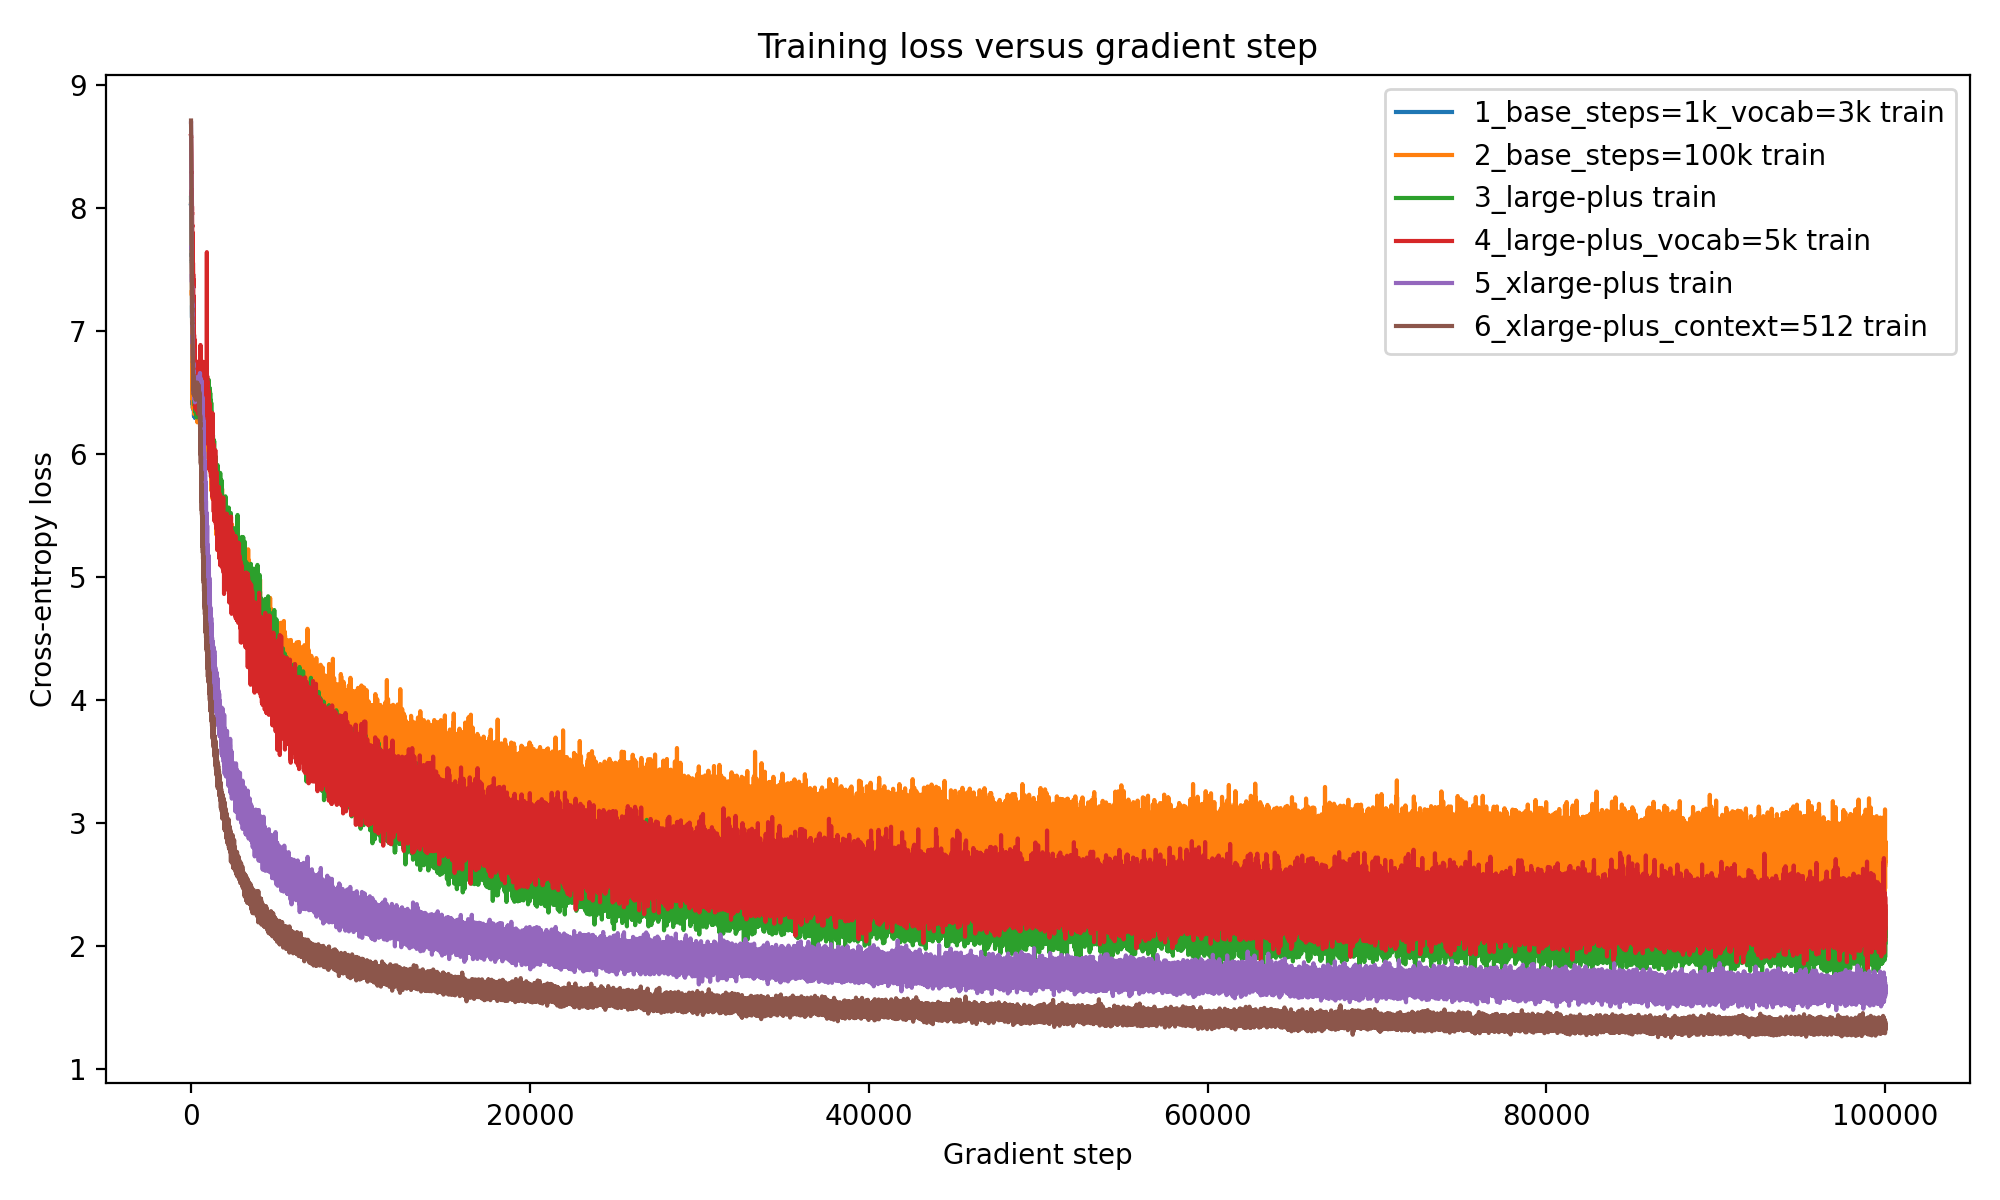

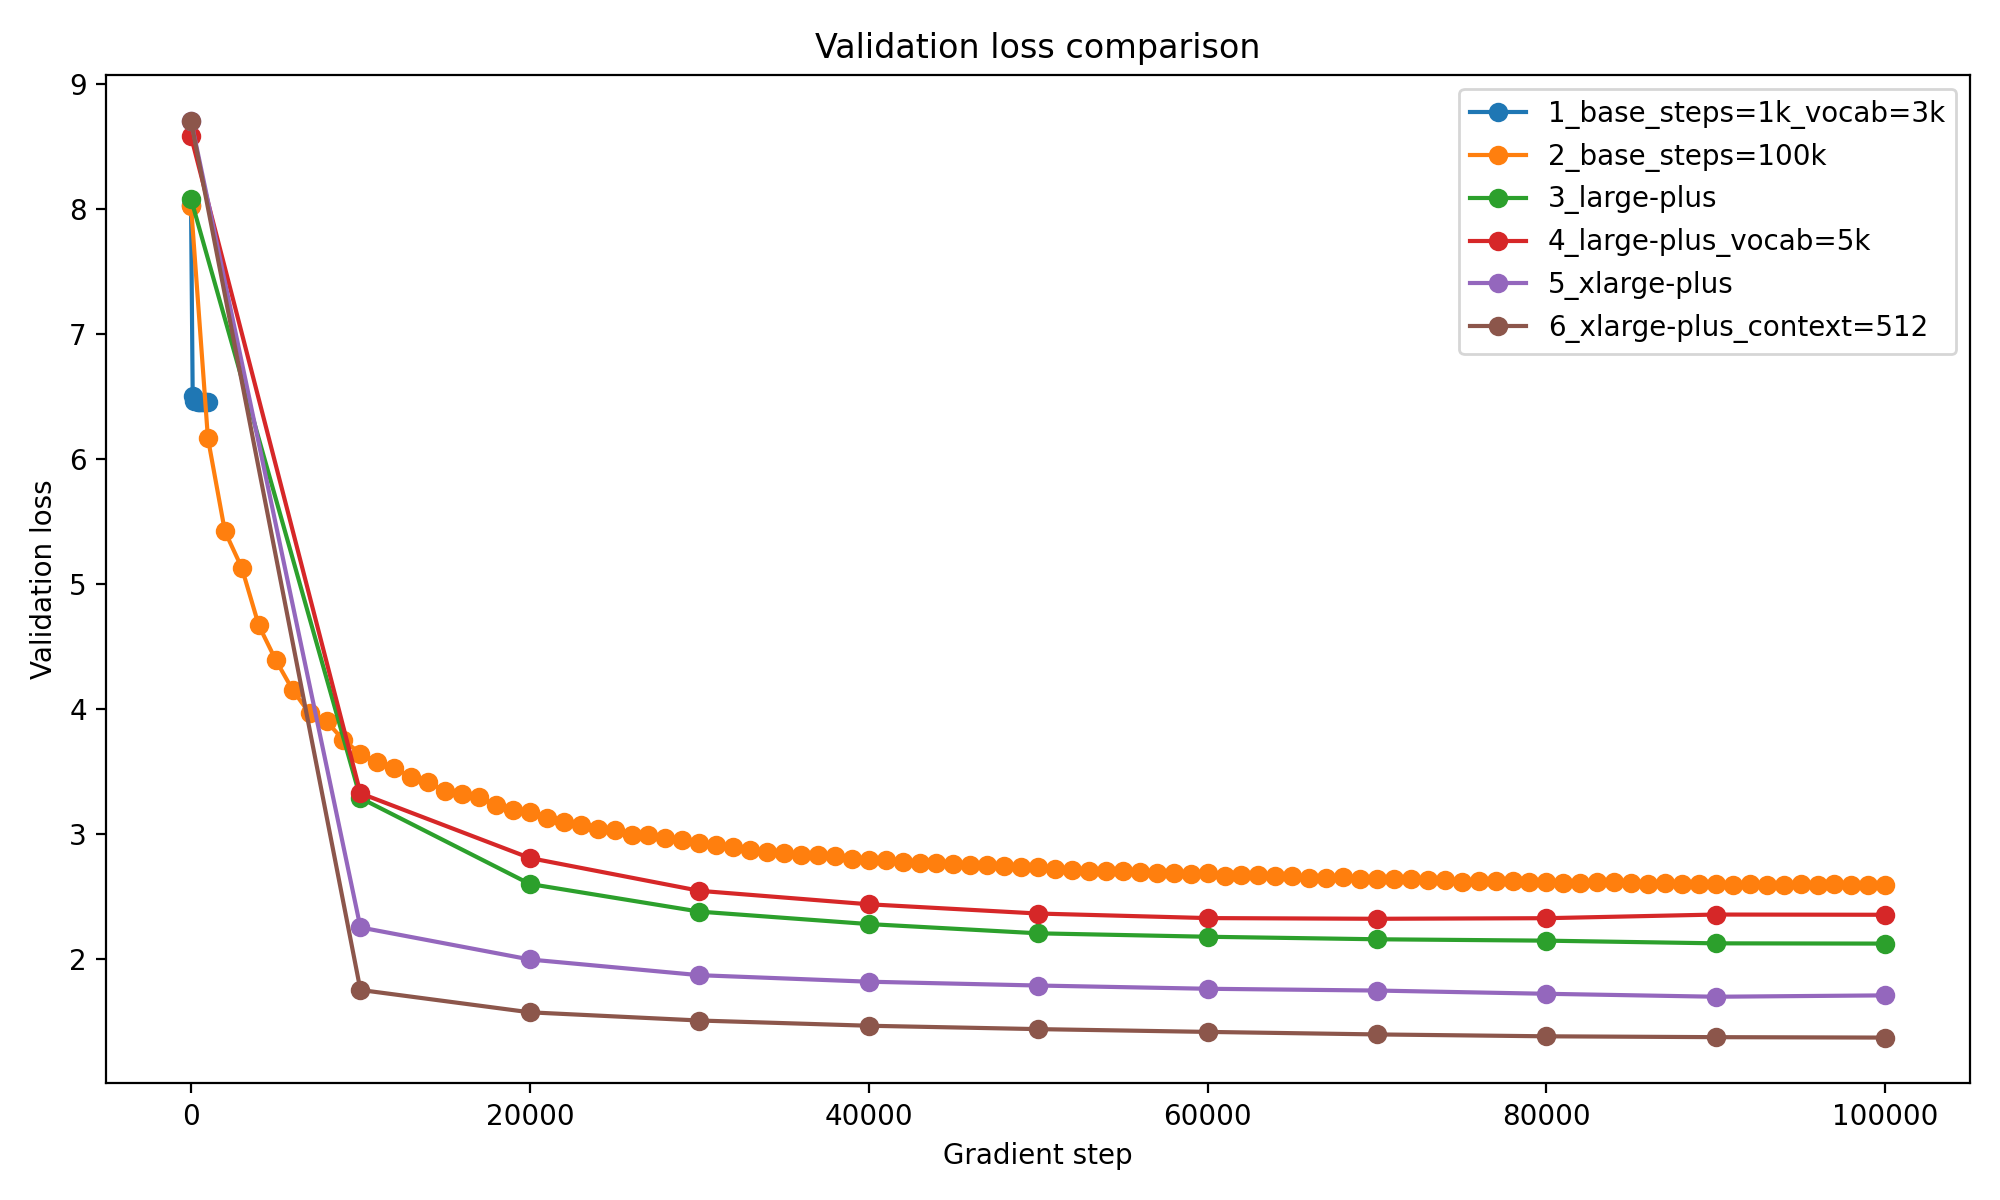

In [9]:
plot_training_curves(
    {k: asdict(v) for k, v in results.items()}, run_config.plots / "training_loss.png"
)
plot_validation_curves(
    {k: asdict(v) for k, v in results.items()}, run_config.plots / "validation_loss.png"
)

display(Image(run_config.plots / "training_loss.png"))
display(Image(run_config.plots / "validation_loss.png"))

And here is the training loop for the final model

In [121]:
configs = [
    (
        ModelConfig(
            name="xlarge-plus",
            d_model=768,
            n_heads=12,
            n_layers=6,
            d_ff=3072,
            batch_size=64,
            learning_rate=2.5e-4,
            weight_decay=0.1,
            warmup_steps=1000,
            max_steps=100000,
            use_amp=torch.cuda.is_available(),
        ),
    )
]

In [ ]:
train_dataset = TokenChunkDataset(
    train_token_memmap_path, train_token_count, global_training_config.context_length
)
valid_dataset = TokenChunkDataset(
    valid_token_memmap_path, valid_token_count, global_training_config.context_length
)

# create the results object 
results: dict[str, dict] = {}

# use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for config in configs:
    metrics_path = run_config.metrics / f"{config.name}.json"
    if metrics_path.exists():
        results[config.name] = json.loads(metrics_path.read_text(encoding="utf-8"))
        continue
    result = train_model(
        run_config,
        global_training_config,
        config,
        tokenizer,
        train_dataset,
        valid_dataset,
        device=device,
    )
    results[config.name] = result
    save_json(result, metrics_path)

    if device.type == "cuda":
        torch.cuda.empty_cache()

## (e) Generative Sampling

In [10]:
generations = load_generations(
    "/Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/runs/hw3-submission/metrics/samples/new-generations.json"
)


The table below illustrates different kinds of generated text based on the prompt, 
across three different model configurations: vocab=500k, context=128, and the large-plus,
xlarge, and xlarge-plus architectures.

We tried this across 3 different temperature and top_k sampling strategies:
- **(temp=0.7, top_k=30)**: these are the results we've displayed below
- **(temp=0.5, top_k=10)**: this was our "conservative" generator
- **(temp=0.8, top_k=50)**: this was our most "creative" generator

Long-span semantic cohesiveness is observed! Grammar is really good as well. Sometimes
the model struggles with direct speech, but the quality is pretty coherent, and shows
good overall structure, even though certain events that are described are logically 
impossible. We do observe a lot of children's story tropes as well - learning lessons,
good morals and habits, etc. 

### Large Context

It does seem like the larger context helps with the overall story structure. The model's
outputs don't drift as much from the central theme. It's got a defined beginning, middle, 
and end. But, the middle of the stories do sometimes suffer from repetition. Perhaps
this can be addressed by further increasing the models capacity.

In [11]:
table = generations_to_dataframe(generations, temperature=0.7, top_k=30)
display(table.head())

model,large-plus,xlarge,xlarge-plus
prompt,,,
A cat named Mia wanted to go outside.,"A cat named Mia wanted to go outside. Mia was happy and excited. She put on her coat and went out.\nAs Mia walked, she saw a big, yellow ball. She picked it up and started to play. She was having a lot of fun. Suddenly, a big wind came. It blew and ran to the park. It was scared and didn't know what to do.\nMia went back to her house. She was happy to be out of the park. Mia and her mom played on theater all day. They had so much fun together.","A cat named Mia wanted to go outside. But the sky was gloomy, and the rain was falling down. Mia felt sad.\nMia's mom said, ""Mia, let's find a way for the rain to go away."" They walked and walked, but they could not find a way to go outside.\nOne day, a kind girl named Lily saw them. She said, ""I can help you find a way to go outside!"" Mia and her mom went outside. Mia was excited and said, ""Yes, please help me!"" And they all went to find a way to go inside the gloomy sky.\nThey found a door and opened it. Inside, they found a big room with lots of toys and games. Mia and her mom played with the toys and had a lot of fun. The wet day turned into a fun day for Mia and her family.","A cat named Mia wanted to go outside. She walked to the door and saw a big box. Mia was very curious, so she went inside the box. Inside, she found a lot of toys.\nMia played with the toys and had lots of fun. Then, Mia saw her mom and dad come to the door. They were happy to see Mia playing. Mia's mom and dad were surprised too. They all played together and had a great day."
Early one morning,"Early one morning she saw a big red ball. She felt a bit scared, so she picked it up and gave it a big hug.\nUnfortunately, the ball began to bounce around in two. She wanted to have it, but it was too late.\nShe tried to reach it but it was too high. Then, a friendly dog came by. The dog was very kind and it licked the ball with its paws. The ball kept bouncing and until it was all better. \nThe ball was so thankful that it had been able to play with the ball. She was so happy that she had made it to the other side of the room. \nThe moral of this story is that it is important to always be careful when trying to catch things. For a little help from then on, no matter how hard or you get to enjoy the fun and have fun.","Early one morning he would wake up early and go to the park. Every morning, he would go to the park to play and have fun with his friends.\nOne night, when he woke up, a big, scary monster appeared in the park. Joe was scared and started to cry. His mommy and daddy came running and said, ""Don't worry, Joey, I will help you get back to the park."" \nMommy and Daddy took Joe to the park and Joe was still crying for a long time. He was so scared he couldn't even notice. He felt sad and angry until he saw a little girl crying. She had a big bag and was crying. Mommy and Daddy were so worried and they went to Jane to comfort her. They took her back to the park and used her hands to open the bag of toys. Joe was so happy to have his special toy back and was no longer afraid of the park.",Early one morning and he was ready to go to the park again soon.
"One day, a group of friends went to the park.","One day, a group of friends went to the park. The sun was shining bright. All the friends liked to play in the grass. They were very happy.\nAt the park, the sun was shining. The friend saw a big tree. The tree had a lot of leaves. The friend wanted to climb the tree. But, no matter how, the tree was not safe.\nThe friends had to wait. The tree did not get the leaves. It was very sad. The other friends did not want to play on the tree. They went home and did not have fun. The day ended of the day, the tree was not a tree, but awake.","One day, a group of friends went to the park. They saw a big tree with a swing. The friends wanted to play on the swings, but they were too high.\nA bird saw them and said, ""I can help you ge

In [15]:
generations = load_generations(
    "/Users/sanch/Obsidian/2025-spring/Notes/242B/Homeworks/hw3/artifacts/runs/hw3-submission/metrics/samples/new-big-context-generations.json"
)
table = generations_to_dataframe(generations, temperature=0.7, top_k=30)
display(table.head())

model,6_xlarge-plus_context=512
prompt,
A cat named Mia wanted to go outside.,"A cat named Mia wanted to go outside. She put on her rain boots and rain boots and went out the door. Mia saw her friend, a dog named Sam. Sam was waiting for her. He was excited to play with Mia.\n""Let's play catch!"" said Sam. Mia and Sam played catch in the rain. They ran and jumped and had lots of fun. After playing, they were both very wet. They went inside to get dry.\nMia's mom saw them and said, ""You two need to dry off and get ready for bed."" Mia and Sam went to the bathroom and dried off. They were ready for bed.\nIn the middle of the night, Mia and Sam went to Mia's bed. They saw a big surprise outside the window. It was a new toy car! They were so happy to see the toy car and started to play with it. The rain made their day even more fun."
Early one morning,"Early one morning to wake up and have some fun with his friends. They were all very excited to go to the park to play.\nWhen they got to the park, they saw a big tree. They wanted to climb it. But it was difficult for them to climb. They tried and tried, but they could not do it. They were sad and sat under the tree.\nThen, something unexpected happened. A big bird came down from the tree. The bird saw the cat and Early and wanted to help. The bird picked up the cat with its strong wings and helped her climb the tree. They all played and had fun together. The cat, Early, and the bird became good friends."
"One day, a group of friends went to the park.","One day, a group of friends went to the park. They wanted to play with their toys. They were very happy.\nAt the park, they found a big ball. They wanted to play with it. But they did not know how to share it. They started to fight over the ball. They were not happy anymore.\nA wise old dog saw them fighting. He said, ""Stop! You must learn how to share. You can both play with the ball."" The friends listened to the wise old dog. They decided to share the ball and play together.\nThe friends played with the ball and had lots of fun. They learned that sharing is good. They became better friends. The group of friends were happy again."
Tom and his best friend Brian were playing with their cars.,"Tom and his best friend Brian were playing with their cars. They liked to make them go fast and make loud noises. They pretended they were racing on a big road.\n""Look at my red car, it's so shiny!"" Tom said, showing off his car. ""It can go very fast and very far!""\n""Look at my blue car, it's so shiny and pretty!"" Brian said, showing off his blue car. ""It can go very fast and very far. And it can get lost in the mud. It can be very dangerous if you drive too fast.""\nTom and Brian smiled. They liked their cars too. They wanted to see them up close. They waited for their cars to stop and then they started to move their cars towards each other. They were having fun.\nBut then, something bad happened. Tom's car hit a rock and bounced off the road. It hit a tree and bounced off the road. It went over the fence and into the street. Tom and Brian saw the car and ran after it. They tried to stop it, but they could not. The car hit a car and bounced away. It was not shiny and shiny anymore. It was broken and hurt.\nTom and Brian were very sad. They loved their cars. They looked at each other and started to cry.\n""I'm sorry, Tom,"" Brian said, ""My car was not shiny and pretty anymore. It was broken and dirty. It was not fun to play with anymore.""\nTom looked at his car and saw that it was broken. He felt very sorry. He loved his car. He did not want to lose it. He loved his friend. He hugged Brian and said, ""I'm sorry, Brian. I was too fast and too curious. I should have been more careful and looked where I was going. I should have been more careful and respectful.""\nBrian hugged him back and said, ""It's okay, Tom. I'm glad you are not too mad at me. I love you too. And I am happy you are not too mad at me. You are a good friend and a goo

### Question (f)

Here are some simple experiment on the learned embeddings of the tokens. We can try to
understand the learned semantics of what each token would be, but performing simple 
arithmetic between tokens, and finding the closets neighbors of the resulting direction

In the three examples:
- Lucy - girl + boy: gives us boys names, kind of as expected
- snake - bad + good: gives us worms, caterpillars, alligators, which are varying 
  degrees of less intense than snakes
- sun - hot + cold: gives us snow, cold, rain, wind!

In [53]:
word_pairs = [
    [
        "▁Lucy",
        "▁girl",
        "▁boy",
    ],
    [
        "▁snake",
        "▁bad",
        "▁good",
    ],
    [
        "▁sun",
        "▁hot",
        "▁cold",
    ],
]

for pair in word_pairs:
    print(f"{pair[0]} - {pair[1]} + {pair[2]} =")
    vec = (
        get_token_vector(tokenizer, model, pair[0])
        - get_token_vector(tokenizer, model, pair[1])
        + get_token_vector(tokenizer, model, pair[2])
    )

    for neighbor in find_closest_tokens(tokenizer, model, vec, top_k=5):
        print(f"     {neighbor}")
    print()


▁Lucy - ▁girl + ▁boy =
     ('▁Lucy', 0.8005343675613403)
     ('▁Timmy', 0.7502890825271606)
     ('▁Tim', 0.7471717596054077)
     ('▁boy', 0.6885653734207153)
     ('▁Tim.', 0.6815358996391296)

▁snake - ▁bad + ▁good =
     ('▁snake', 0.6920951008796692)
     ('▁snake.', 0.48493337631225586)
     ('▁good', 0.47660502791404724)
     ('▁turtle', 0.4573569595813751)
     ('▁neck', 0.4455905258655548)

▁sun - ▁hot + ▁cold =
     ('▁sun', 0.764910101890564)
     ('▁wind', 0.501511812210083)
     ('▁sunsh', 0.4477587640285492)
     ('▁snow', 0.4441651403903961)
     ('▁sky', 0.44201546907424927)

